In [ ]:
"""
CNN - Phân loại CIFAR-10
Tương tự cấu trúc kernel farzadnekouei/cifar-10-image-classification-with-cnn
"""
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os, zipfile, urllib.request, shutil, random
from PIL import Image

# ─────────────────────────────────────────────
# 1. Cấu hình ban đầu
# ─────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

Device: cuda


In [ ]:
# ─────────────────────────────────────────────
# 2. Load dữ liệu CIFAR-10 (tự tải, không cần Kaggle API)
# ─────────────────────────────────────────────
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True,  num_workers=2)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=128, shuffle=False, num_workers=2)

In [ ]:
# ─────────────────────────────────────────────
# 3. Định nghĩa model CNN
#
# Kiến trúc:
#   Input  (3, 32, 32)
#   Conv1 (3→32, k=3, pad=1) → ReLU → Conv2 (32→32) → ReLU → MaxPool → (32, 16, 16)
#   Conv3 (32→64, k=3, pad=1) → ReLU → Conv4 (64→64) → ReLU → MaxPool → (64, 8, 8)
#   Flatten → 4096
#   FC (4096 → 256) → ReLU → Dropout → FC (256 → 10)
# ─────────────────────────────────────────────
class CIFAR10_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc1   = nn.Linear(64 * 8 * 8, 256)
        self.fc2   = nn.Linear(256, 10)
        self.relu  = nn.ReLU()
        self.dropout = nn.Dropout(0.4)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.relu(self.conv3(x))
        x = self.pool(self.relu(self.conv4(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

model = CIFAR10_CNN().to(device)
print(model)

CIFAR10_CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.4, inplace=False)
)


In [ ]:
# ─────────────────────────────────────────────
# 4. Loss và Optimizer
# ─────────────────────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# ─────────────────────────────────────────────
# 5. Hàm đánh giá
# ─────────────────────────────────────────────
def evaluate(model, loader):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss_sum += criterion(outputs, labels).item() * images.size(0)
            correct  += (outputs.argmax(1) == labels).sum().item()
            total    += labels.size(0)
    return loss_sum / total, correct / total

In [ ]:
# ─────────────────────────────────────────────
# 6. Huấn luyện
# ─────────────────────────────────────────────
num_epochs = 12
loss_history, acc_history = [], []
test_loss_history, test_acc_history = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total
    test_loss, test_acc = evaluate(model, test_loader)

    loss_history.append(train_loss); acc_history.append(train_acc)
    test_loss_history.append(test_loss); test_acc_history.append(test_acc)

    print(f'Epoch {epoch+1}/{num_epochs} | Train loss: {train_loss:.4f} acc: {train_acc*100:.2f}% '
          f'| Test loss: {test_loss:.4f} acc: {test_acc*100:.2f}%')

Epoch 1/12 | Train loss: 1.4821 acc: 46.26% | Test loss: 1.1221 acc: 59.19%
Epoch 2/12 | Train loss: 1.0531 acc: 62.82% | Test loss: 0.9653 acc: 65.69%
Epoch 3/12 | Train loss: 0.8590 acc: 69.82% | Test loss: 0.7919 acc: 72.54%
Epoch 4/12 | Train loss: 0.7339 acc: 74.01% | Test loss: 0.7275 acc: 74.77%
Epoch 5/12 | Train loss: 0.6375 acc: 77.63% | Test loss: 0.6938 acc: 75.61%
Epoch 6/12 | Train loss: 0.5622 acc: 80.14% | Test loss: 0.6840 acc: 76.31%
Epoch 7/12 | Train loss: 0.4812 acc: 82.85% | Test loss: 0.7320 acc: 75.61%
Epoch 8/12 | Train loss: 0.4228 acc: 84.74% | Test loss: 0.7236 acc: 76.83%
Epoch 9/12 | Train loss: 0.3731 acc: 86.62% | Test loss: 0.7950 acc: 75.40%
Epoch 10/12 | Train loss: 0.3250 acc: 88.18% | Test loss: 0.7967 acc: 76.96%
Epoch 11/12 | Train loss: 0.2838 acc: 89.78% | Test loss: 0.7878 acc: 77.24%
Epoch 12/12 | Train loss: 0.2554 acc: 90.66% | Test loss: 0.9019 acc: 76.56%


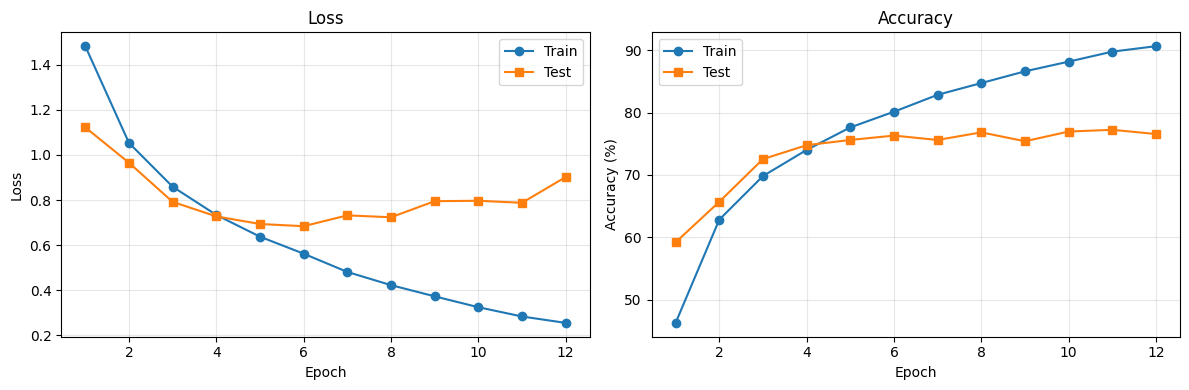

In [ ]:
# ─────────────────────────────────────────────
# 7. Vẽ đường Loss & Accuracy
# ─────────────────────────────────────────────
epochs = range(1, num_epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, loss_history,      'o-', label='Train')
axes[0].plot(epochs, test_loss_history, 's-', label='Test')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Loss')

axes[1].plot(epochs, [a*100 for a in acc_history],      'o-', label='Train')
axes[1].plot(epochs, [a*100 for a in test_acc_history], 's-', label='Test')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title('Accuracy')
plt.tight_layout(); plt.show()

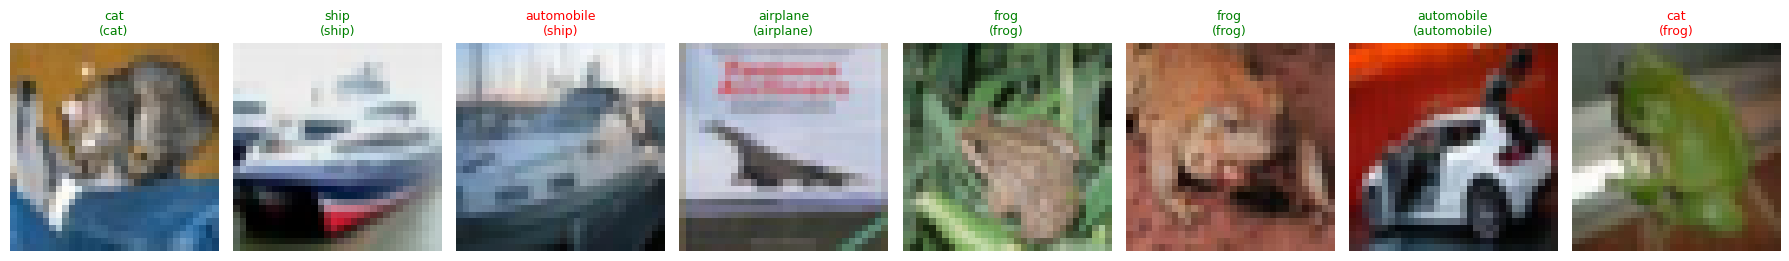

In [ ]:
# ─────────────────────────────────────────────
# 8. Trực quan: model dự đoán
# ─────────────────────────────────────────────
def unnormalize(img):
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1)
    std  = torch.tensor([0.2470, 0.2435, 0.2616]).view(3,1,1)
    return (img.cpu() * std + mean).permute(1, 2, 0).clamp(0, 1)

model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)
with torch.no_grad():
    preds = model(images).argmax(1)

fig, axes = plt.subplots(1, 8, figsize=(18, 3))
for i in range(8):
    axes[i].imshow(unnormalize(images[i]))
    color = 'green' if preds[i] == labels[i] else 'red'
    axes[i].set_title(f'{CLASSES[preds[i]]}\n({CLASSES[labels[i]]})', color=color, fontsize=9)
    axes[i].axis('off')
plt.tight_layout(); plt.show()

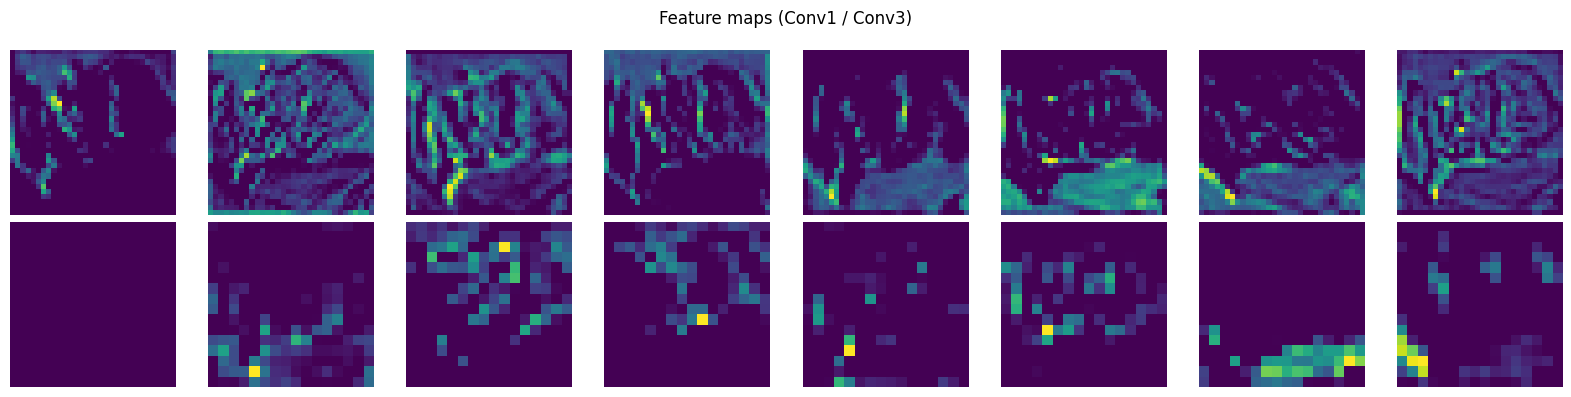

In [ ]:
# ─────────────────────────────────────────────
# 9. Trực quan: feature maps
# ─────────────────────────────────────────────
img = images[0].unsqueeze(0)
with torch.no_grad():
    fmap1 = torch.relu(model.conv1(img))
    fmap2 = torch.relu(model.conv3(model.pool(torch.relu(model.conv2(fmap1)))))

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axes[0, i].imshow(fmap1[0, i].cpu(), cmap='viridis'); axes[0, i].axis('off')
    axes[1, i].imshow(fmap2[0, i].cpu(), cmap='viridis'); axes[1, i].axis('off')
plt.suptitle('Feature maps (Conv1 / Conv3)')
plt.tight_layout(); plt.show()